In [1]:
# .set 文件 =  EEG 数据包（信号 + 事件 + 元信息）
# .locs 文件 = 电极的"地图"（每个电极在头上的坐标）

In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [42]:
f_name = "../data/eeglab2026/sample_data/eeglab_data.set"
raw = mne.io.read_raw_eeglab(f_name, preload=False)

Reading D:\workspace\practice_mne_demo\notebooks\..\data\eeglab2026\sample_data\eeglab_data.fdt


D:\Miniconda\envs\mne_demo_env\lib\site-packages\mne\viz\_mpl_figure.py:2160: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  self.canvas.draw_idle()
D:\Miniconda\envs\mne_demo_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


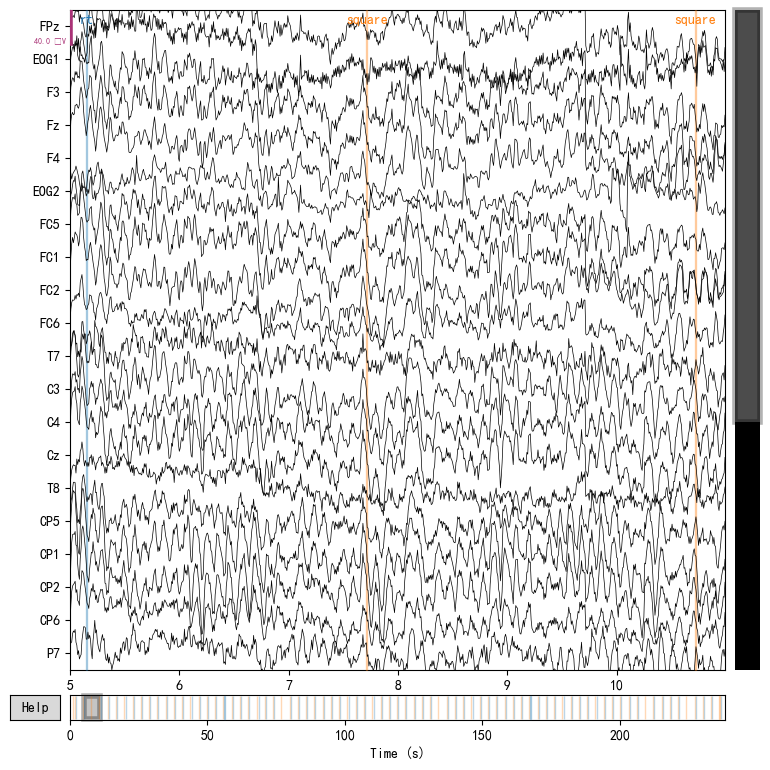

In [43]:
# 绘制从第5秒开始，持续时长6秒的原始数据
raw.plot(start=5, duration=6)
plt.show()

D:\Miniconda\envs\mne_demo_env\lib\site-packages\mne\viz\_mpl_figure.py:2160: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  self.canvas.draw_idle()
D:\Miniconda\envs\mne_demo_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


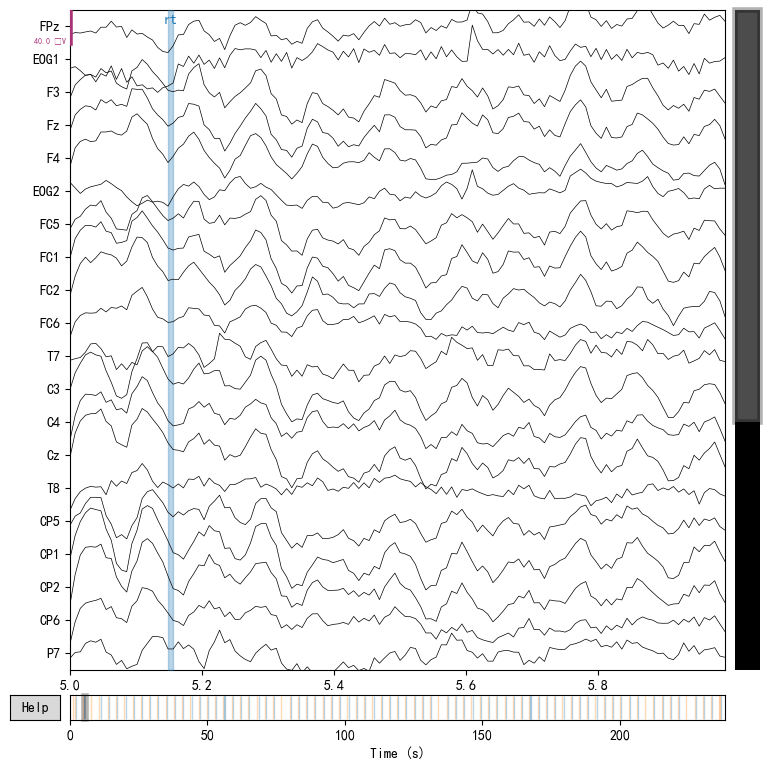

In [44]:
# 相当于放大
raw.plot(start=5, duration=1)
plt.show()

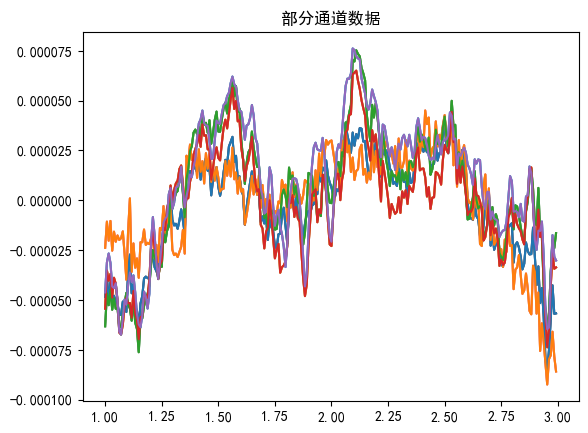

In [9]:
# 建议跳过，只理解，不运行
sfreq = raw.info['sfreq']
# 提取数据：选取前 5 个通道（索引 0~4），时间范围从第 1 秒到第 3 秒
# int(sfreq*1) 和 int(sfreq*3) 将物理时间转换为对应的采样点索引
# data 形状为 (5, n_times)，times 为对应的时间轴（单位：秒）
data, times = raw[:5, int(sfreq * 1):int(sfreq * 3)]
plt.plot(times, data.T)
plt.title("部分通道数据")
plt.show()

In [46]:
# 读取.locs文件
print(raw.info['ch_names'])

"""
FP	Frontal Polar	额极（最靠前）
F	Frontal	额叶
FC	Frontal-Central	额-中央交界
T	Temporal	颞叶（太阳穴附近）
C	Central	中央区（运动皮层上方）
CP	Central-Parietal	中央-顶叶交界
P	Parietal	顶叶
PO	Parieto-Occipital	顶-枕交界
O	Occipital	枕叶（视觉皮层）
EOG	Electrooculogram	眼电
------------------------------
奇数（1,3,5,7）	左侧半球
偶数（2,4,6,8）	右侧半球
z	中线（zero）
"""

['FPz', 'EOG1', 'F3', 'Fz', 'F4', 'EOG2', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'C4', 'Cz', 'T8', 'CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2']


'\nFP\tFrontal Polar\t额极（最靠前）\nF\tFrontal\t额叶\nFC\tFrontal-Central\t额-中央交界\nT\tTemporal\t颞叶（太阳穴附近）\nC\tCentral\t中央区（运动皮层上方）\nCP\tCentral-Parietal\t中央-顶叶交界\nP\tParietal\t顶叶\nPO\tParieto-Occipital\t顶-枕交界\nO\tOccipital\t枕叶（视觉皮层）\nEOG\tElectrooculogram\t眼电\n------------------------------\n奇数（1,3,5,7）\t左侧半球\n偶数（2,4,6,8）\t右侧半球\nz\t中线（zero）\n'

In [47]:
montage = mne.channels.read_custom_montage("../data/eeglab2026/sample_data/eeglab_chan32.locs")
raw.set_montage(montage)

<RawEEGLAB | eeglab_data.fdt, 32 x 30504 (238.3 s), ~48 KiB, data not loaded>

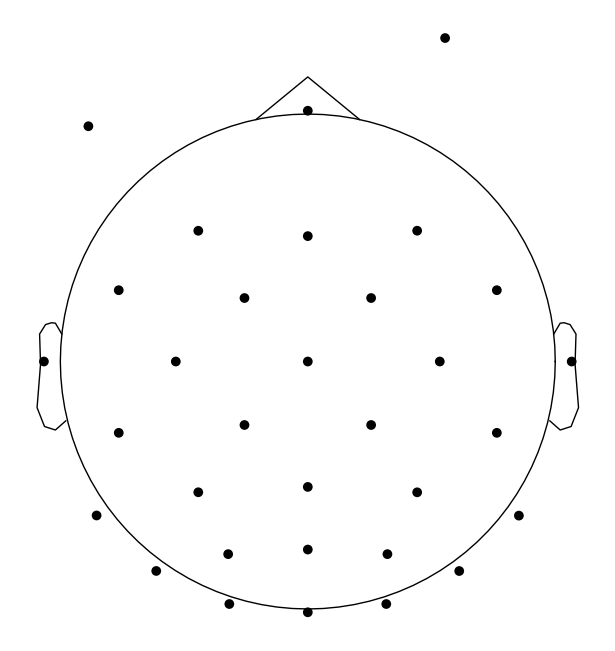

In [48]:
# 绘制电极位置
raw.plot_sensors()
plt.show()

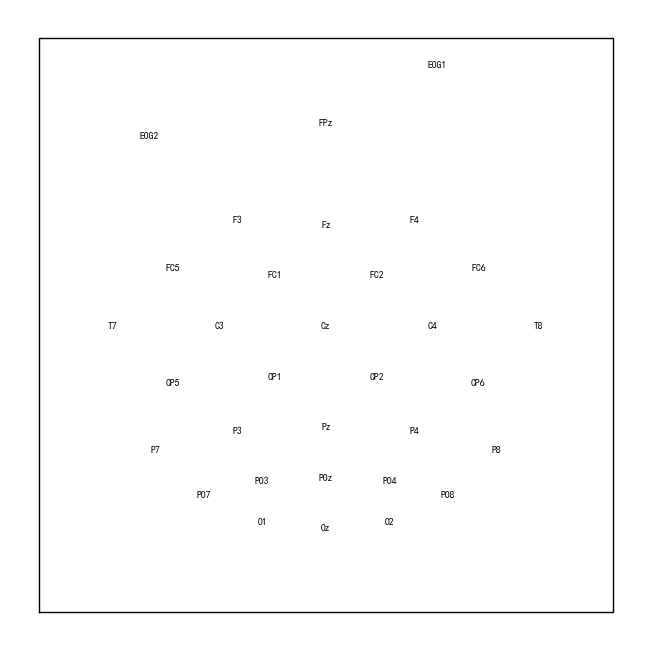

In [49]:
# 显示通道名称
layout_from_raw = mne.channels.make_eeg_layout(raw.info)
layout_from_raw.plot()
plt.show()

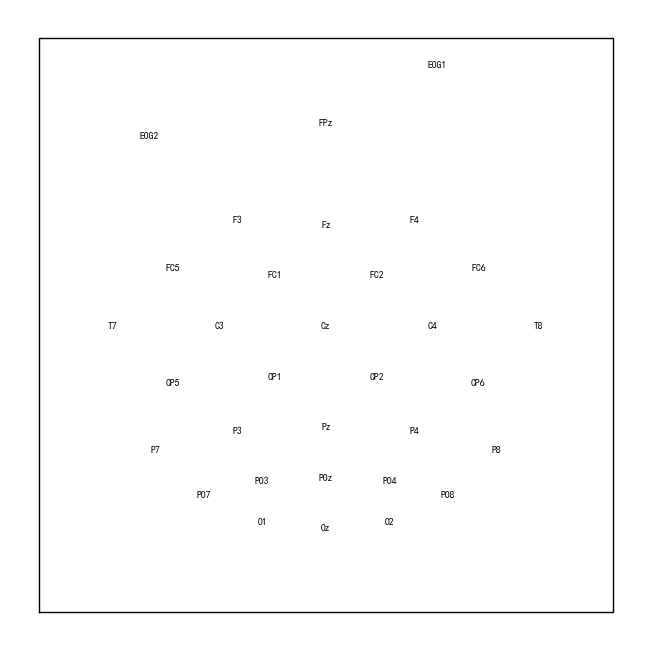

In [50]:
# 显示通道名称
layout_from_raw = mne.channels.find_layout(raw.info, ch_type='eeg')
layout_from_raw.plot()
plt.show()

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


D:\Miniconda\envs\mne_demo_env\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


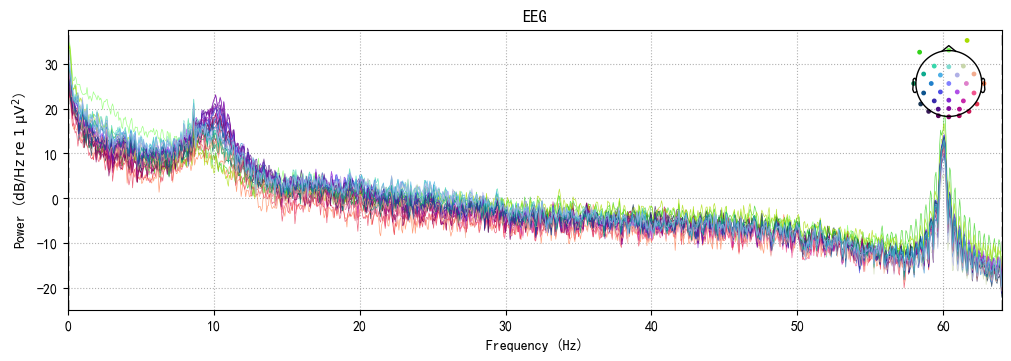

In [51]:
# 绘制各通道的功率谱密度
raw.plot_psd()
plt.show()

Effective window size : 10.008 (s)
Plotting power spectral density (dB=True).


D:\Miniconda\envs\mne_demo_env\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


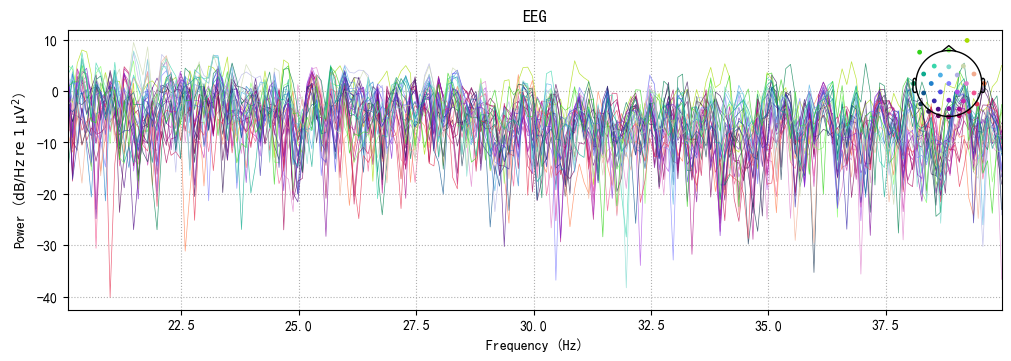

In [52]:
# 绘制指定区间的 所有通道的 功率谱密度

# 旧版本
# raw.plot_psd(fmin=30, fmax=70, tmin=40, tmax=50, spatial_colors=True)

# 新版本 注意这里需要
raw.compute_psd(fmin=20, fmax=40, tmin=0, tmax=10).plot(spatial_colors=True)
plt.show()

Effective window size : 10.008 (s)
Plotting power spectral density (dB=True).


D:\Miniconda\envs\mne_demo_env\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


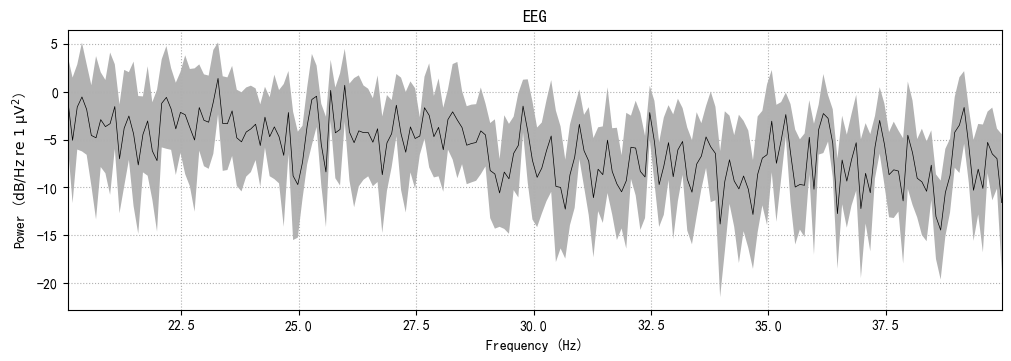

In [53]:
# 绘制指定区间的 平均的 功率谱密度
raw.compute_psd(fmin=20, fmax=40, tmin=0, tmax=10).plot(average=True)
plt.show()

In [20]:
#